# Query session database

This notebooks expects that you have run the [workflow.ipynb](workflow.ipynb) notebook first to create and fill the session database.

In [1]:
from pathlib import Path

import duckdb

from protein_detective.db import db_path

Configure [%sql magic](https://jupysql.ploomber.io/en/latest/quick-start.html#querying) to use the session database.

In [2]:
session_dir = Path("session1")
database = db_path(session_dir)
%load_ext sql
conn = duckdb.connect(database)
%sql conn --alias duckdb

Loading configurations from /home/verhoes/git/protein-detective/protein-detective/pyproject.toml.

Settings changed:

Config,value
displaylimit,100


In [3]:
%sql SELECT * FROM proteins

Running query in 'duckdb'

uniprot_acc
A6NMT0
A8MQ14
A0A087WUV0
A6NFD8
A8MT65
A8K830
A6NDZ8
A0A2R8Y619
A6NFQ7
A6NHT5


In [4]:
%sql SELECT * FROM pdbs

Running query in 'duckdb'

pdb_id,method,resolution,pdb_file
4NE5,X-Ray_Crystallography,2.5,downloads/pdb4ne5.ent.gz
7XHO,Electron_Microscopy,3.2899999618530273,downloads/pdb7xho.ent.gz
7R5S,Electron_Microscopy,2.8299999237060547,downloads/pdb7r5s.ent.gz
4NDY,X-Ray_Crystallography,7.0,downloads/pdb4ndy.ent.gz
4NE3,X-Ray_Crystallography,1.7999999523162842,downloads/pdb4ne3.ent.gz
7YWX,Electron_Microscopy,12.0,downloads/pdb7ywx.ent.gz
4E45,X-Ray_Crystallography,2.0,downloads/pdb4e45.ent.gz
7XHN,Electron_Microscopy,3.7100000381469727,downloads/pdb7xhn.ent.gz
4DRB,X-Ray_Crystallography,2.630000114440918,downloads/pdb4drb.ent.gz
4NE1,X-Ray_Crystallography,6.5,downloads/pdb4ne1.ent.gz


In [5]:
%sql SELECT * FROM proteins_pdbs

Running query in 'duckdb'

uniprot_acc,pdb_id,uniprot_chains,single_chain_pdb_file
A8MT69,4NE5,B/D/F/H=8-81,single_chain/A8MT69_pdb4ne5.ent_B2A.pdb
A8MT69,7XHO,X=1-81,single_chain/A8MT69_pdb7xho.ent_X2A.pdb
A8MT69,7R5S,X=1-81,single_chain/A8MT69_pdb7r5s.ent_X2A.pdb
A8MT69,4NDY,B/D/H/L/M/N/U/V/W/X=8-81,single_chain/A8MT69_pdb4ndy.ent_B2A.pdb
A8MT69,4NE3,B=8-81,single_chain/A8MT69_pdb4ne3.ent_B2A.pdb
A8MT69,7YWX,X=1-81,single_chain/A8MT69_pdb7ywx.ent_X2A.pdb
A8MT69,4E45,B/D/G/I/L/N=1-81,single_chain/A8MT69_pdb4e45.ent_B2A.pdb
A8MT69,7XHN,X=1-81,single_chain/A8MT69_pdb7xhn.ent_X2A.pdb
A8MT69,4DRB,J/K/L/M/N/O=1-81,single_chain/A8MT69_pdb4drb.ent_J2A.pdb
A8MT69,4NE1,B/D/H/L/M/N/U/V/W/X/Z/b/d/h/i/j/o/p/q/r=8-81,single_chain/A8MT69_pdb4ne1.ent_B2A.pdb


In [6]:
%sql SELECT * FROM alphafolds LIMIT 1

Running query in 'duckdb'

uniprot_acc,summary,pdb_file,pae_file
A0A087WUV0,"{""entryId"": ""AF-A0A087WUV0-F1"", ""gene"": ""Unknown"", ""sequenceChecksum"": ""5DE83E4BE25B68BD"", ""sequenceVersionDate"": ""2014-10-29"", ""uniprotAccession"": ""A0A087WUV0"", ""uniprotId"": ""A0A087WUV0_HUMAN"", ""uniprotDescription"": ""Uncharacterized protein"", ""taxId"": 9606, ""organismScientificName"": ""Homo sapiens"", ""uniprotStart"": 1, ""uniprotEnd"": 522, ""uniprotSequence"": ""MEPEGRGSLFEDSDLLHAGNPKENDVTAVLLTPGSQELMIRDMAEALTQWRQLNSPQGDVPEKPRNLVLLGLPISTPDVISQLEHEEELEREVSKAASQKHWETIPESKELTPEKDISEEESAPGVLIVRFSKESSSECEDSLESQQENHEKHLIQEAVTEKSSRERSYQSDEFRRNCTQRSLLVQQQGERLHHCDSFKNNLKQNSDIIRHERICAGKKPWKCNECEKAFSYYSAFVLHQRIHTGEKPYECNECGKAFSQSIHLTLHQRIHTGEKPYECHECGKAFSHRSALIRHHIIHTGEKPYECNECGKAFNQSSYLTQHQRIHTGEKPYECNECGKAFSQSTFLTQHQVIHTGEKPYKCNECGKAFSDRSGLIQHQRTHTGERPYECNECGKAFGYCSALTQHQRTHTGEKPYKCNDCAKAFSDRSALIRHQRTHTGEKPYKCKDCGKAFSQSSSLTKHQKTHTGEKPYKCKECGKAFSQSSSLSQHQKTHAGVKTKKYVQALSEHLTFGQHKRIHTG"", ""modelCreatedDate"": ""2022-06-01"", ""latestVersion"": 4, ""allVersions"": [1, 2, 3, 4], ""bcifUrl"": ""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-model_v4.bcif"", ""cifUrl"": ""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-model_v4.cif"", ""pdbUrl"": ""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-model_v4.pdb"", ""paeImageUrl"": ""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-predicted_aligned_error_v4.png"", ""paeDocUrl"": ""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-predicted_aligned_error_v4.json"", ""amAnnotationsUrl"": ""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-aa-substitutions.csv"", ""amAnnotationsHg19Url"": null, ""amAnnotationsHg38Url"": ""https://alphafold.ebi.ac.uk/files/AF-A0A087WUV0-F1-hg38.csv"", ""isReviewed"": false, ""isReferenceProteome"": true}",downloads/AF-A0A087WUV0-F1-model_v4.pdb,downloads/AF-A0A087WUV0-F1-predicted_aligned_error_v4.json


In [7]:
%sql SELECT count(*) FROM alphafolds

Running query in 'duckdb'

count_star()
55


In [8]:
# Fetch fields from inside summary
%sql SELECT uniprot_acc, summary.taxId, summary.uniprotStart, summary.uniprotEnd, summary.gene FROM alphafolds

Running query in 'duckdb'

uniprot_acc,taxId,uniprotStart,uniprotEnd,gene
A0A087WUV0,9606,1,522,"""Unknown"""
A0A0C5B5G6,9606,1,16,"""MT-RNR1"""
A0A0U1RQI7,9606,1,1052,"""KLF18"""
A0A1B0GTS1,9606,1,333,"""HSFX4"""
A0A1B0GVZ6,9606,1,204,"""MBD3L2B"""
A0A1B0GWH4,9606,1,333,"""HSFX3"""
A0A1W2PPF3,9606,1,345,"""DUXB"""
A0A1W2PPK0,9606,1,400,"""Unknown"""
A0A1W2PPM1,9606,1,405,"""CPHXL"""
A0A1W2PQ73,9606,1,354,"""ERFL"""


In [9]:
%%sql
SELECT 
f.confidence, f.min_threshold, f.max_threshold,
density_filtered_alphafolds.*, 
alphafolds.summary.uniprotStart, 
alphafolds.summary.uniprotEnd, 
length(alphafolds.summary.uniprotSequence) AS uniprot_length
FROM density_filtered_alphafolds
JOIN density_filters  AS f USING (density_filter_id) 
JOIN alphafolds USING (uniprot_acc)
LIMIT 100;

Running query in 'duckdb'

confidence,min_threshold,max_threshold,density_filter_id,uniprot_acc,nr_residues_above_confidence,keep,pdb_file,uniprotStart,uniprotEnd,uniprot_length
70.0,100,500,1,A0A087WUV0,283,True,density_filtered/AF-A0A087WUV0-F1-model_v4.pdb,1,522,524
70.0,100,500,1,A0A0C5B5G6,10,False,None,1,16,18
70.0,100,500,1,A0A0U1RQI7,192,True,density_filtered/AF-A0A0U1RQI7-F1-model_v4.pdb,1,1052,1054
70.0,100,500,1,A0A1B0GTS1,116,True,density_filtered/AF-A0A1B0GTS1-F1-model_v4.pdb,1,333,335
70.0,100,500,1,A0A1B0GVZ6,54,False,None,1,204,206
70.0,100,500,1,A0A1B0GWH4,117,True,density_filtered/AF-A0A1B0GWH4-F1-model_v4.pdb,1,333,335
70.0,100,500,1,A0A1W2PPF3,124,True,density_filtered/AF-A0A1W2PPF3-F1-model_v4.pdb,1,345,347
70.0,100,500,1,A0A1W2PPK0,71,False,None,1,400,402
70.0,100,500,1,A0A1W2PPM1,68,False,None,1,405,407
70.0,100,500,1,A0A1W2PQ73,86,False,None,1,354,356


## Powerfit

In [10]:
result = %sql SELECT powerfit_run_id, options.target, options.resolution FROM powerfit_runs;

Running query in 'duckdb'

In [11]:
result

powerfit_run_id,target,resolution
10,"""../../powerfit-tutorial/ribosome-KsgA.map""",13


In [12]:
powerfit_run_id = result[0][0]
powerfit_run_dir = session_dir.absolute() / "powerfit" / str(powerfit_run_id)
solutions_pattern = str(powerfit_run_dir / "*" / "solutions.out")
solutions_pattern

'/home/verhoes/git/protein-detective/protein-detective/docs/session1/powerfit/10/*/solutions.out'

In [13]:
!ls {solutions_pattern}

/home/verhoes/git/protein-detective/protein-detective/docs/session1/powerfit/10/A8MT69_pdb4e45.ent_B2A/solutions.out
/home/verhoes/git/protein-detective/protein-detective/docs/session1/powerfit/10/A8MT69_pdb4ne5.ent_B2A/solutions.out
/home/verhoes/git/protein-detective/protein-detective/docs/session1/powerfit/10/A8MT69_pdb7xho.ent_X2A/solutions.out
/home/verhoes/git/protein-detective/protein-detective/docs/session1/powerfit/10/AF-A8MT65-F1-model_v4/solutions.out


In [14]:
%%sql SELECT 
    * EXCLUDE (filename),
    parse_path(filename)[-3] AS powerfit_run_id,
    parse_path(filename)[-2] AS structure,
FROM
    read_csv('{{solutions_pattern}}', filename=True)
LIMIT 10;

Running query in 'duckdb'

rank,cc,Fish-z,rel-z,x,y,z,a11,a12,a13,a21,a22,a23,a31,a32,a33,powerfit_run_id,structure
1,0.432,0.463,10.091,227.18,242.53,211.83,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,10,A8MT69_pdb4e45.ent_B2A
2,0.418,0.445,9.705,224.11,264.02,153.5,0.797,0.0,0.604,0.604,-0.0,-0.797,0.0,1.0,-0.0,10,A8MT69_pdb4e45.ent_B2A
3,0.41,0.436,9.499,254.81,267.09,125.87,0.632,-0.548,0.548,-0.548,-0.816,-0.184,0.548,-0.184,-0.816,10,A8MT69_pdb4e45.ent_B2A
4,0.405,0.43,9.373,196.48,227.18,236.39,-0.0,0.0,1.0,0.0,1.0,0.0,-1.0,0.0,-0.0,10,A8MT69_pdb4e45.ent_B2A
5,0.403,0.428,9.328,141.22,150.43,187.27,-0.548,0.184,0.816,-0.632,0.548,-0.548,-0.548,-0.816,-0.184,10,A8MT69_pdb4e45.ent_B2A
6,0.403,0.428,9.327,144.29,107.45,193.41,0.0,-0.797,0.604,0.0,-0.604,-0.797,1.0,0.0,0.0,10,A8MT69_pdb4e45.ent_B2A
7,0.4,0.424,9.249,227.18,242.53,205.69,0.362,-0.896,0.258,0.258,0.362,0.896,-0.896,-0.258,0.362,10,A8MT69_pdb4e45.ent_B2A
8,0.399,0.423,9.219,276.3,248.67,153.5,-0.0,1.0,0.0,1.0,-0.0,0.0,0.0,0.0,-1.0,10,A8MT69_pdb4e45.ent_B2A
9,0.399,0.423,9.219,214.9,217.97,193.41,0.184,-0.816,0.548,0.548,0.548,0.632,-0.816,0.184,0.548,10,A8MT69_pdb4e45.ent_B2A
10,0.398,0.421,9.184,214.9,187.27,214.9,-1.0,-0.0,0.0,0.0,-0.797,-0.604,0.0,-0.604,0.797,10,A8MT69_pdb4e45.ent_B2A


In [15]:
%sql SELECT density_filter_id, uniprot_acc, pdb_file, parse_filename(pdb_file, true) FROM density_filtered_alphafolds WHERE keep=True

Running query in 'duckdb'

density_filter_id,uniprot_acc,pdb_file,"parse_filename(pdb_file, CAST('t' AS BOOLEAN))"
1,A0A087WUV0,density_filtered/AF-A0A087WUV0-F1-model_v4.pdb,AF-A0A087WUV0-F1-model_v4
1,A0A0U1RQI7,density_filtered/AF-A0A0U1RQI7-F1-model_v4.pdb,AF-A0A0U1RQI7-F1-model_v4
1,A0A1B0GTS1,density_filtered/AF-A0A1B0GTS1-F1-model_v4.pdb,AF-A0A1B0GTS1-F1-model_v4
1,A0A1B0GWH4,density_filtered/AF-A0A1B0GWH4-F1-model_v4.pdb,AF-A0A1B0GWH4-F1-model_v4
1,A0A1W2PPF3,density_filtered/AF-A0A1W2PPF3-F1-model_v4.pdb,AF-A0A1W2PPF3-F1-model_v4
1,A0A1W2PQL4,density_filtered/AF-A0A1W2PQL4-F1-model_v4.pdb,AF-A0A1W2PQL4-F1-model_v4
1,A1YPR0,density_filtered/AF-A1YPR0-F1-model_v4.pdb,AF-A1YPR0-F1-model_v4
1,A2RRD8,density_filtered/AF-A2RRD8-F1-model_v4.pdb,AF-A2RRD8-F1-model_v4
1,A6NDX5,density_filtered/AF-A6NDX5-F1-model_v4.pdb,AF-A6NDX5-F1-model_v4
1,A6NFD8,density_filtered/AF-A6NFD8-F1-model_v4.pdb,AF-A6NFD8-F1-model_v4


In [16]:
%%sql SELECT uniprot_acc, pdb_id, single_chain_pdb_file, parse_filename(single_chain_pdb_file, true) AS structure
    FROM proteins_pdbs
    WHERE single_chain_pdb_file IS NOT NULL 

Running query in 'duckdb'

uniprot_acc,pdb_id,single_chain_pdb_file,structure
A8MT69,4NE5,single_chain/A8MT69_pdb4ne5.ent_B2A.pdb,A8MT69_pdb4ne5.ent_B2A
A8MT69,7XHO,single_chain/A8MT69_pdb7xho.ent_X2A.pdb,A8MT69_pdb7xho.ent_X2A
A8MT69,7R5S,single_chain/A8MT69_pdb7r5s.ent_X2A.pdb,A8MT69_pdb7r5s.ent_X2A
A8MT69,4NDY,single_chain/A8MT69_pdb4ndy.ent_B2A.pdb,A8MT69_pdb4ndy.ent_B2A
A8MT69,4NE3,single_chain/A8MT69_pdb4ne3.ent_B2A.pdb,A8MT69_pdb4ne3.ent_B2A
A8MT69,7YWX,single_chain/A8MT69_pdb7ywx.ent_X2A.pdb,A8MT69_pdb7ywx.ent_X2A
A8MT69,4E45,single_chain/A8MT69_pdb4e45.ent_B2A.pdb,A8MT69_pdb4e45.ent_B2A
A8MT69,7XHN,single_chain/A8MT69_pdb7xhn.ent_X2A.pdb,A8MT69_pdb7xhn.ent_X2A
A8MT69,4DRB,single_chain/A8MT69_pdb4drb.ent_J2A.pdb,A8MT69_pdb4drb.ent_J2A
A8MT69,4NE1,single_chain/A8MT69_pdb4ne1.ent_B2A.pdb,A8MT69_pdb4ne1.ent_B2A


Join the solutions with their source structure.

In [17]:
%%sql
SELECT
    * EXCLUDE (pdb_file, single_chain_pdb_file, af_id, uniprot_acc),
    '{{session_dir}}' || '/' || COALESCE(pdb_file, single_chain_pdb_file) AS pdb_file,
    COALESCE(uniprot_acc, af_id) AS uniprot_acc,
FROM (
    SELECT 
    parse_path(filename)[-3] AS powerfit_run_id,
    parse_path(filename)[-2] AS structure,
    rank, cc, fishz, relz,
    [x,y,z]::FLOAT[3] AS translation,
    [a11, a12, a12, a21, a22, a23, a31, a32, a33]::FLOAT[9] AS rotation,
FROM
    read_csv('{{solutions_pattern}}', filename=True, normalize_names=True) 
)
LEFT JOIN (
    SELECT density_filter_id, uniprot_acc AS af_id, pdb_file, parse_filename(pdb_file, true) AS structure 
    FROM density_filtered_alphafolds WHERE keep=True
) AS a USING (structure)
LEFT JOIN (
    SELECT uniprot_acc, pdb_id, single_chain_pdb_file, parse_filename(single_chain_pdb_file, true) AS structure
    FROM proteins_pdbs
    WHERE single_chain_pdb_file IS NOT NULL 
) AS p USING (structure)
ORDER BY cc DESC
LIMIT 5
-- Uncomment offset to see a alphafold solution
-- OFFSET 5000

Running query in 'duckdb'

powerfit_run_id,structure,rank,cc,fishz,relz,translation,rotation,density_filter_id,pdb_id,pdb_file,uniprot_acc
10,A8MT69_pdb4e45.ent_B2A,1,0.432,0.463,10.091,"(227.17999267578125, 242.52999877929688, 211.8300018310547)","(0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0)",None,4E45,session1/single_chain/A8MT69_pdb4e45.ent_B2A.pdb,A8MT69
10,A8MT69_pdb4ne5.ent_B2A,1,0.423,0.452,10.053,"(227.17999267578125, 242.52999877929688, 214.89999389648438)","(0.0, -0.0, -0.0, -0.6039999723434448, 0.796999990940094, 0.0, 0.796999990940094, 0.6039999723434448, 0.0)",None,4NE5,session1/single_chain/A8MT69_pdb4ne5.ent_B2A.pdb,A8MT69
10,A8MT69_pdb7xho.ent_X2A,1,0.423,0.452,10.253,"(208.75999450683594, 193.41000366210938, 257.8800048828125)","(-0.5479999780654907, 0.8159999847412109, 0.8159999847412109, 0.6320000290870667, 0.5479999780654907, -0.5479999780654907, -0.5479999780654907, -0.18400000035762787, -0.8159999847412109)",None,7XHO,session1/single_chain/A8MT69_pdb7xho.ent_X2A.pdb,A8MT69
10,A8MT69_pdb4e45.ent_B2A,2,0.418,0.445,9.705,"(224.11000061035156, 264.0199890136719, 153.5)","(0.796999990940094, 0.0, 0.0, 0.6039999723434448, -0.0, -0.796999990940094, 0.0, 1.0, -0.0)",None,4E45,session1/single_chain/A8MT69_pdb4e45.ent_B2A.pdb,A8MT69
10,A8MT69_pdb4ne5.ent_B2A,2,0.414,0.441,9.815,"(227.17999267578125, 138.14999389648438, 227.17999267578125)","(-0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 1.0, 0.0, -0.0)",None,4NE5,session1/single_chain/A8MT69_pdb4ne5.ent_B2A.pdb,A8MT69


In [3]:
from protein_detective.db import powerfit_solutions

In [4]:
df = powerfit_solutions(session_dir, conn)
df

,powerfit_run_id,structure,rank,cc,fishz,relz,translation,rotation,density_filter_id,pdb_id,pdb_file,uniprot_acc
0,10,A8MT69_pdb4e45.ent_B2A,1,0.432,0.463,10.091,"[227.18, 242.53, 211.83]","[0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0]",<NA>,4E45,session1/single_chain/A8MT69_pdb4e45.ent_B2A.pdb,A8MT69
1,10,A8MT69_pdb4ne5.ent_B2A,1,0.423,0.452,10.053,"[227.18, 242.53, 214.9]","[0.0, -0.0, -0.0, -0.604, 0.797, 0.0, 0.797, 0...",<NA>,4NE5,session1/single_chain/A8MT69_pdb4ne5.ent_B2A.pdb,A8MT69
2,10,A8MT69_pdb7xho.ent_X2A,1,0.423,0.452,10.253,"[208.76, 193.41, 257.88]","[-0.548, 0.816, 0.816, 0.632, 0.548, -0.548, -...",<NA>,7XHO,session1/single_chain/A8MT69_pdb7xho.ent_X2A.pdb,A8MT69
3,10,A8MT69_pdb4e45.ent_B2A,2,0.418,0.445,9.705,"[224.11, 264.02, 153.5]","[0.797, 0.0, 0.0, 0.604, -0.0, -0.797, 0.0, 1....",<NA>,4E45,session1/single_chain/A8MT69_pdb4e45.ent_B2A.pdb,A8MT69
4,10,A8MT69_pdb4ne5.ent_B2A,2,0.414,0.441,9.815,"[227.18, 138.15, 227.18]","[-0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 1.0, 0.0, -0.0]",<NA>,4NE5,session1/single_chain/A8MT69_pdb4ne5.ent_B2A.pdb,A8MT69
...,...,...,...,...,...,...,...,...,...,...,...,...
5233,10,AF-A8MT65-F1-model_v4,1486,0.130,0.131,5.308,"[208.76, 257.88, 187.27]","[0.548, -0.184, -0.184, 0.548, 0.816, 0.184, 0...",1,None,session1/density_filtered/AF-A8MT65-F1-model_v...,A8MT65
5234,10,AF-A8MT65-F1-model_v4,1487,0.130,0.131,5.303,"[233.32, 174.99, 273.23]","[0.362, -0.258, -0.258, -0.258, 0.896, -0.362,...",1,None,session1/density_filtered/AF-A8MT65-F1-model_v...,A8MT65
5235,10,AF-A8MT65-F1-model_v4,1488,0.130,0.130,5.293,"[196.48, 184.2, 156.57]","[0.184, 0.548, 0.548, -0.816, 0.548, -0.184, -...",1,None,session1/density_filtered/AF-A8MT65-F1-model_v...,A8MT65
5236,10,AF-A8MT65-F1-model_v4,1489,0.129,0.130,5.280,"[239.46, 144.29, 174.99]","[-0.548, -0.632, -0.632, -0.816, 0.548, -0.184...",1,None,session1/density_filtered/AF-A8MT65-F1-model_v...,A8MT65


<Axes: title={'center': 'Histogram of CC Values'}, ylabel='Frequency'>

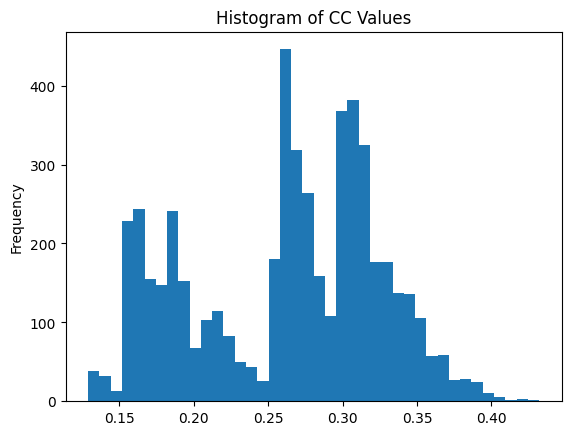

In [7]:
df["cc"].plot(kind="hist", title="Histogram of CC Values", bins=40)